# 🔬 Disease Prediction from Medical Data
**Task 4** — Predict disease possibility from patient data using classification algorithms.

**Datasets:** Heart Disease · Diabetes · Breast Cancer (UCI ML Repository)  
**Algorithms:** SVM · Logistic Regression · Random Forest · XGBoost


In [1]:
# Install dependencies (run once)
%pip install numpy pandas scikit-learn xgboost matplotlib seaborn joblib tqdm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay,
)
from xgboost import XGBClassifier

plt.rcParams["figure.dpi"] = 110
print("✅ All imports successful")

✅ All imports successful


## 2. Data Loading

> **Breast Cancer** uses sklearn's built-in dataset — no download needed.  
> **Heart Disease** and **Diabetes** require a CSV (see README for links).

In [3]:
HEART_COLS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

DIABETES_COLS = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

def load_heart_disease(csv_path):
    df = pd.read_csv(csv_path, header=None, names=HEART_COLS, na_values="?")
    df["target"] = (df["target"] > 0).astype(int)
    return df, "target"

def load_diabetes(csv_path):
    df = pd.read_csv(csv_path)
    if list(df.columns) == list(range(df.shape[1])):
        df.columns = DIABETES_COLS
    zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
    for col in zero_invalid:
        if col in df.columns:
            df[col] = df[col].replace(0, np.nan)
    return df, "Outcome"

def load_breast_cancer_builtin():
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df["target"] = data.target
    return df, "target"

print("✅ Loader functions defined")

✅ Loader functions defined


In [4]:
# ── Load Breast Cancer (built-in — no file needed) ──
df, TARGET_COL = load_breast_cancer_builtin()

# ── To use Heart Disease instead, uncomment: ──
# df, TARGET_COL = load_heart_disease("data/heart.csv")

# ── To use Diabetes instead, uncomment: ──
# df, TARGET_COL = load_diabetes("data/diabetes.csv")

print(f"Dataset shape : {df.shape}")
print(f"Target column : {TARGET_COL}")
print(f"\nClass distribution:")
print(df[TARGET_COL].value_counts())
df.head()

Dataset shape : (569, 31)
Target column : target

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Exploratory Data Analysis

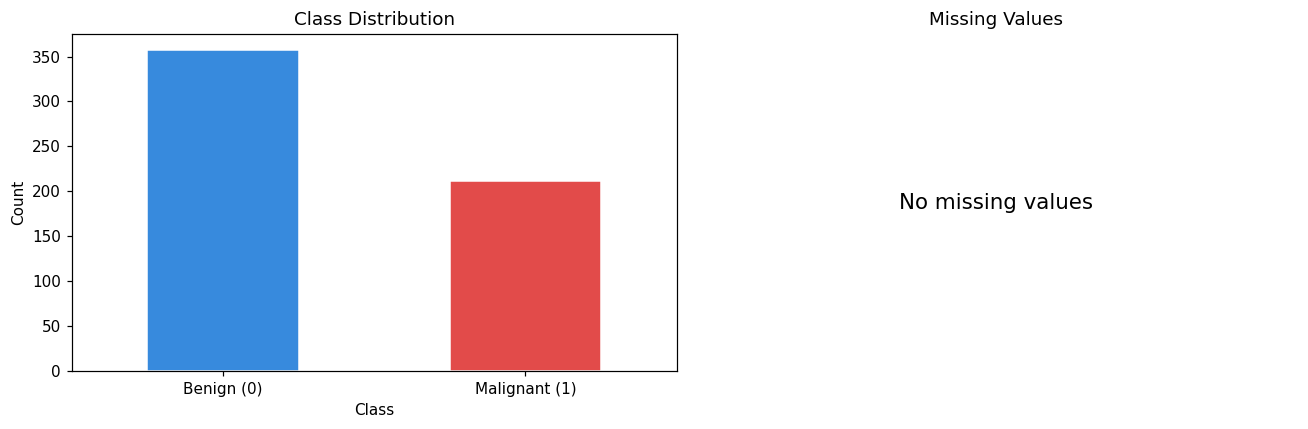


Dataset stats:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                0.05   

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df[TARGET_COL].value_counts().plot(kind="bar", ax=axes[0], color=["#378ADD", "#E24B4A"], edgecolor="white")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Benign (0)", "Malignant (1)"], rotation=0)

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    missing.plot(kind="bar", ax=axes[1], color="#EF9F27")
    axes[1].set_title("Missing Values per Feature")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=14)
    axes[1].set_title("Missing Values")
    axes[1].axis("off")

plt.tight_layout()
plt.show()
print(f"\nDataset stats:\n{df.describe().round(2)}")

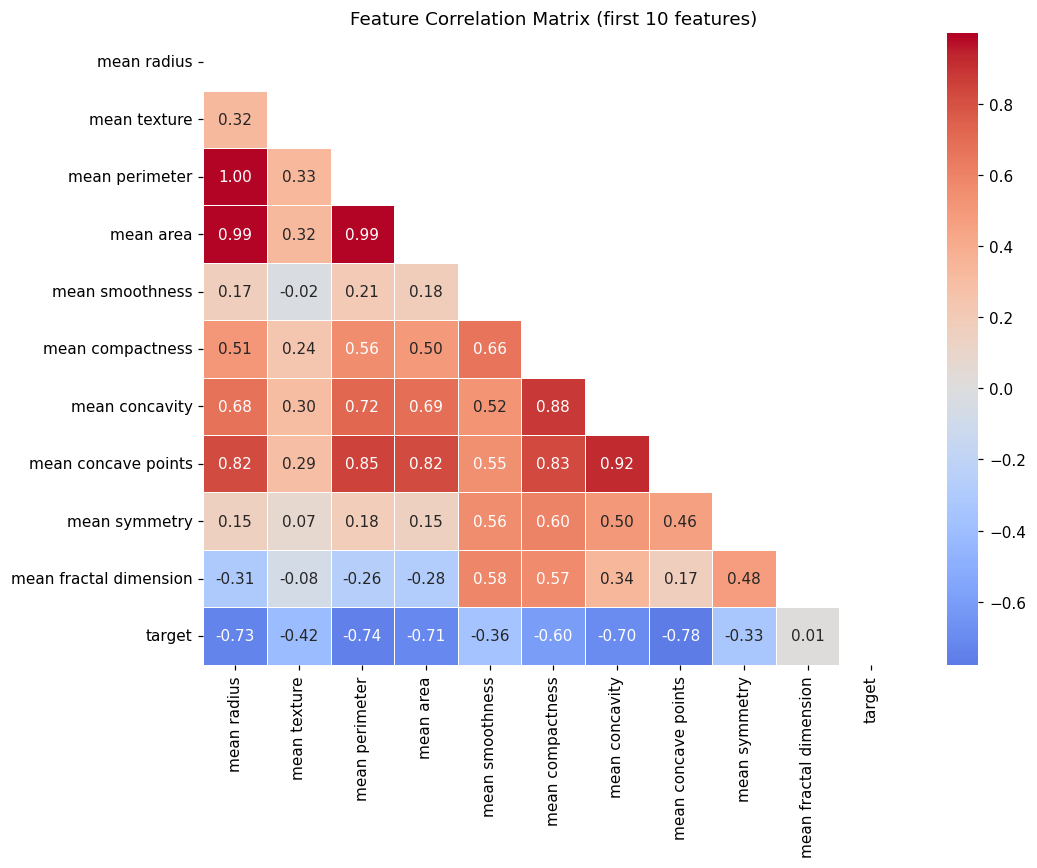

In [6]:
# Correlation heatmap (first 10 features for readability)
top_features = df.columns[:10].tolist()
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[top_features + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Matrix (first 10 features)")
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [7]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].values
FEATURE_NAMES = list(X.columns)

# Median imputation
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test  size : {X_test.shape}")
print(f"Features   : {X_train.shape[1]}")
print(f"Classes    : {np.unique(y)}")

Train size : (455, 30)
Test  size : (114, 30)
Features   : 30
Classes    : [0 1]


## 5. Model Definitions

In [8]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "SVM":                 SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                          eval_metric="logloss", random_state=42, n_jobs=-1),
}
print(f"Models to train: {list(MODELS.keys())}")

Models to train: ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']


## 6. Training & Cross-Validation

In [9]:
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for name, model in MODELS.items():
    print(f"Training {name}...", end=" ")

    # 5-fold CV
    cv_res = cross_validate(model, X_train, y_train,
                            cv=skf, scoring=scoring, n_jobs=-1)

    # Fit on full train set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = {
        "model":  model,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "test": {
            "accuracy":  accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall":    recall_score(y_test, y_pred, zero_division=0),
            "f1":        f1_score(y_test, y_pred, zero_division=0),
            "roc_auc":   roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        },
        "cv": {m: {"mean": cv_res[f"test_{m}"].mean(), "std": cv_res[f"test_{m}"].std()}
               for m in scoring},
    }
    acc = results[name]["test"]["accuracy"]
    print(f"✅  test_acc={acc:.4f}")

print("\nAll models trained!")

Training Logistic Regression... ✅  test_acc=0.9825
Training SVM... ✅  test_acc=0.9825
Training Random Forest... ✅  test_acc=0.9561
Training XGBoost... ✅  test_acc=0.9474

All models trained!


## 7. Results Leaderboard

In [10]:
rows = []
for name, res in results.items():
    rows.append({
        "Model":     name,
        "Accuracy":  round(res["test"]["accuracy"],  4),
        "Precision": round(res["test"]["precision"], 4),
        "Recall":    round(res["test"]["recall"],    4),
        "F1":        round(res["test"]["f1"],        4),
        "ROC-AUC":   round(res["test"]["roc_auc"],   4) if res["test"]["roc_auc"] else "N/A",
        "CV Acc (mean±std)": f"{res['cv']['accuracy']['mean']:.4f} ± {res['cv']['accuracy']['std']:.4f}",
    })

leaderboard = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
leaderboard

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV Acc (mean±std)
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954,0.9780 ± 0.0098
1,SVM,0.9825,0.9861,0.9861,0.9861,0.9950,0.9670 ± 0.0155
2,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9932,0.9626 ± 0.0179
3,XGBoost,0.9474,0.9459,0.9722,0.9589,0.9917,0.9670 ± 0.0139


## 8. Model Comparison Charts

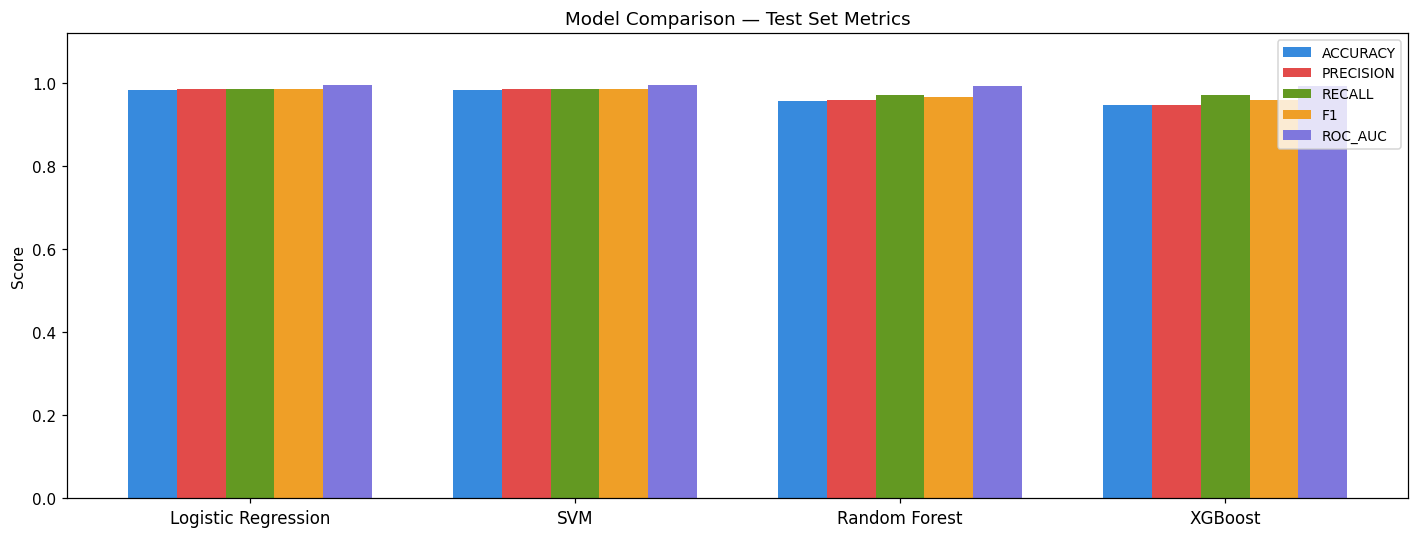

In [11]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc"]
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.15
colors = ["#378ADD", "#E24B4A", "#639922", "#EF9F27", "#7F77DD"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, metric in enumerate(metrics_to_plot):
    vals = [results[n]["test"].get(metric) or 0 for n in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric.upper(), color=colors[i])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Metrics")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

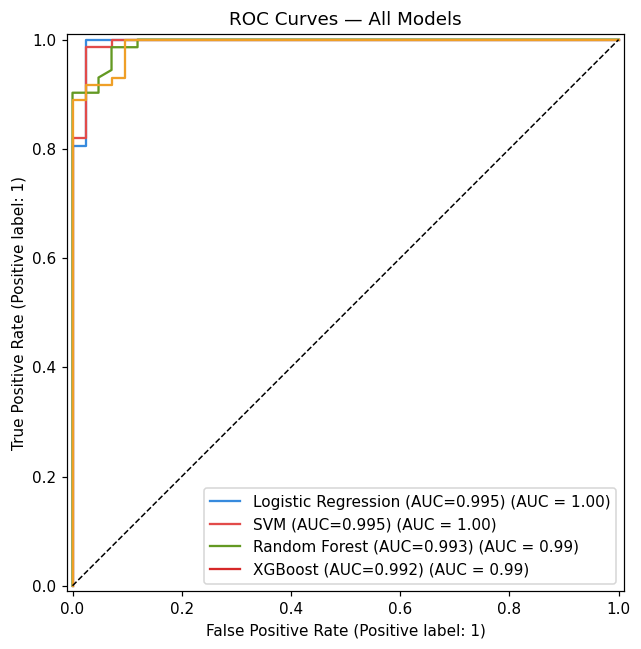

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#378ADD", "#E24B4A", "#639922", "#EF9F27"]

for (name, res), color in zip(results.items(), colors):
    if res["y_prob"] is not None:
        disp = RocCurveDisplay.from_predictions(
            y_test, res["y_prob"],
            name=f"{name} (AUC={res['test']['roc_auc']:.3f})",
            ax=ax
        )
        disp.line_.set_color(color)  # apply color after the fact

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curves — All Models")
plt.tight_layout()
plt.show()

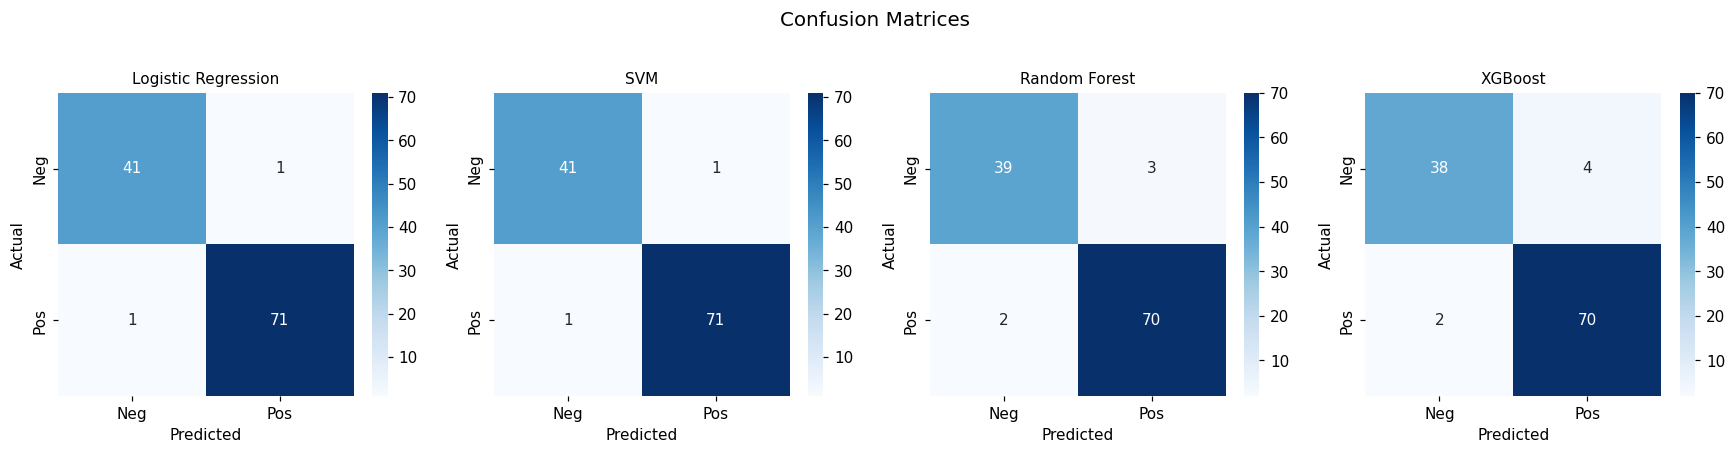

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance (Random Forest & XGBoost)

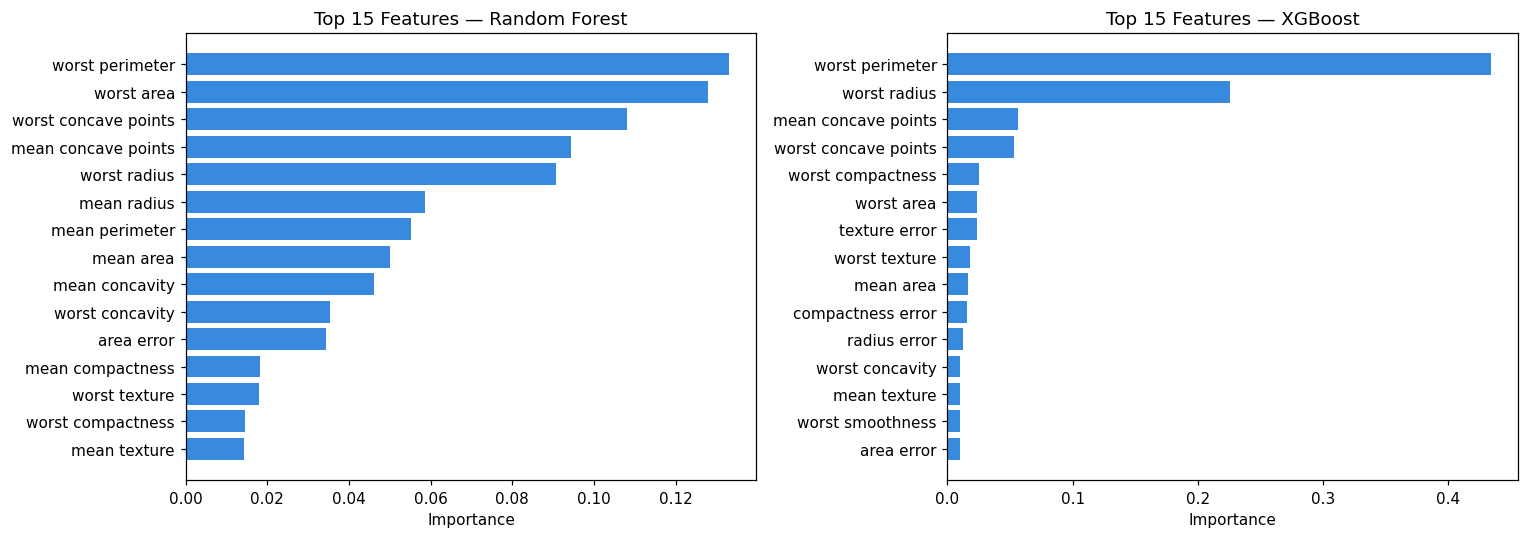

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_n = 15

for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    model = results[name]["model"]
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]
    ax.barh(
        [FEATURE_NAMES[i] for i in reversed(idx)],
        importances[list(reversed(idx))],
        color="#378ADD"
    )
    ax.set_title(f"Top {top_n} Features — {name}")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 10. Detailed Classification Report

In [15]:
for name, res in results.items():
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, res["y_pred"],
                                 target_names=["No Disease", "Disease"]))

  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.98      0.98      0.98        42
     Disease       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  SVM
              precision    recall  f1-score   support

  No Disease       0.98      0.98      0.98        42
     Disease       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  Random Forest
              precision    recall  f1-score   support

  No Disease       0.95      0.93      0.94        42
     Disease       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0

## 11. Save Best Model

In [16]:
import os
os.makedirs("outputs", exist_ok=True)

# Find best model by F1
best_name = max(results, key=lambda n: results[n]["test"]["f1"])
best_model = results[best_name]["model"]

joblib.dump(best_model, "outputs/best_model.pkl")
joblib.dump(scaler,     "outputs/scaler.pkl")
joblib.dump(imputer,    "outputs/imputer.pkl")

print(f"✅ Best model: {best_name} (F1={results[best_name]['test']['f1']:.4f})")
print("Saved: outputs/best_model.pkl, scaler.pkl, imputer.pkl")

✅ Best model: Logistic Regression (F1=0.9861)
Saved: outputs/best_model.pkl, scaler.pkl, imputer.pkl


## 12. Single Patient Inference Demo

In [17]:
def predict_patient(feature_vector, model, scaler, imputer, feature_names):
    """Predict disease probability for one patient."""
    X = np.array([[feature_vector.get(f, np.nan) for f in feature_names]])
    X = imputer.transform(X)
    X = scaler.transform(X)
    pred = model.predict(X)[0]
    prob = model.predict_proba(X)[0, 1] if hasattr(model, "predict_proba") else float(pred)
    return {"prediction": int(pred), "probability": round(float(prob), 4),
            "label": "DISEASE DETECTED 🔴" if pred == 1 else "NO DISEASE 🟢"}

# Example: use mean values of the test set as a sample patient
sample = {feat: float(round(X_test[0][i], 4)) for i, feat in enumerate(FEATURE_NAMES)}
result = predict_patient(sample, best_model, scaler, imputer, FEATURE_NAMES)

print(f"Prediction  : {result['label']}")
print(f"Probability : {result['probability']:.1%}")

Prediction  : DISEASE DETECTED 🔴
Probability : 100.0%
